# Image as Matrix
In computer science and digital processing, an image is fundamentally a grid (or array) of numbers representing pixels

Grayscale Images: Represented as a 2D array. Each position \([x, y]\) contains a single number representing the pixel's brightness, usually ranging from 0 (black) to 255 (white)

Color Images (RGB): Represented as a 3D array. The third dimension contains 3 separate layers (channels) for Red, Green, and Blue. For example, the array shape is typically written as \((Height, Width, 3)\)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img=Image.open("cat.jpg")
print(type(img))
img_array=np.array(img)

print(img_array.shape)


<class 'PIL.JpegImagePlugin.JpegImageFile'>
(148, 269, 3)


Role of plt.imshow(img_array): It converts your image matrix or data into a grid of colors in the background. It prepares and arranges the image for display.

Role of plt.show(): It does not have the ability to process any data. Its only job is to render the prepped window or canvas onto the screen so you can actually see it.

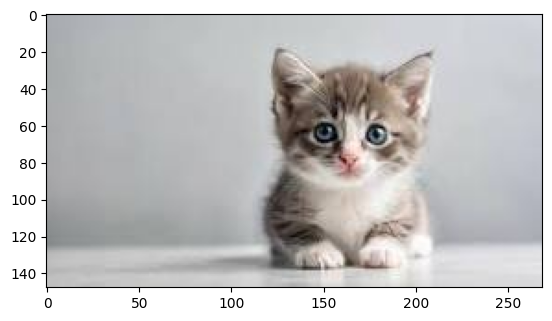

In [3]:
plt.imshow(img_array)
plt.show()

>crop

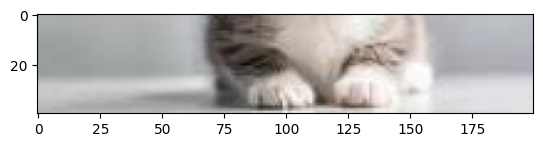

(148, 269, 3)


In [4]:
crop=img_array[100:140,50:250]

plt.imshow(crop)
plt.show()
print(img_array.shape)


>Horizontal Flip

      ::-1: Selects all columns but steps backward by 1. This reverses the horizontal order of pixels.

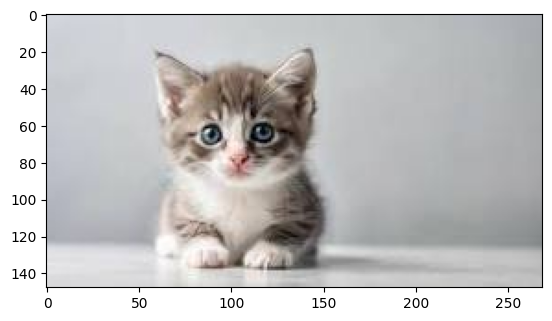

(148, 269, 3)


In [5]:
horflipped = img_array[:, ::-1]

plt.imshow(horflipped)
plt.show()
print(img_array.shape)

>Vertical Flip


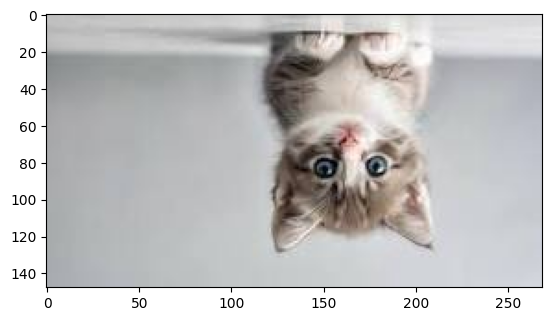

(148, 269, 3)


In [6]:
verflipped = img_array[::-1,:]

plt.imshow(verflipped)
plt.show()
print(img_array.shape)

>Bright

use clip cuz pixel range [0,250]

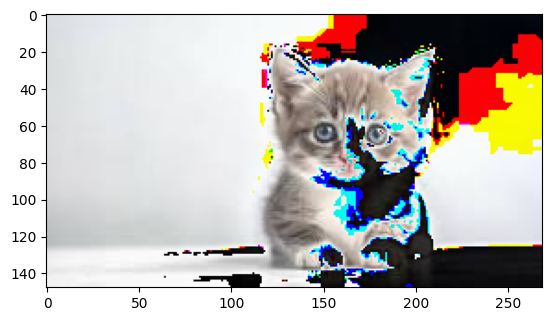

(148, 269, 3)


In [7]:
bright = img_array + 50
bright=np.clip(bright ,0,250)


plt.imshow(bright)
plt.show()
print(img_array.shape)

>convert to grayscale

RGB image:3 channels

Grayscale:1 intensity value

Luminosity (Weighted) Method: This is the most accurate method because it accounts for human visual perception—our eyes are most sensitive to green, then red, and least to blue.
Formula:
0.299R+0.587G+0.114B

Average Method: Simply averages the three channels. It is easier to calculate but may result in less visual depth.Formula: (Gray = R + G + B\3)

Data Compression: Grayscale images use only 8 bits per pixel (one channel) compared to 24 bits for RGB (three channels), significantly reducing file size.

Image Processing: Many complex algorithms (like edge detection or face recognition) work faster and more reliably on single-channel grayscale data.

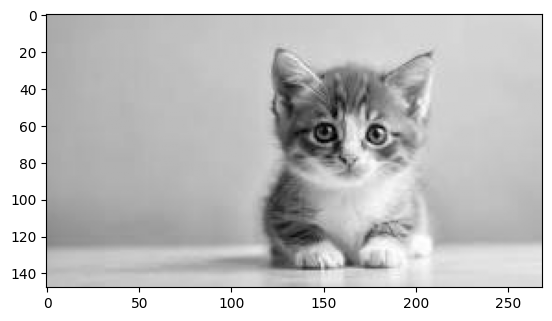

(148, 269, 3)


In [8]:
gray = np.dot(
    img_array[..., :3], #img_array[:, :, :3]
    [0.299, 0.587, 0.114]
)

plt.imshow(gray, cmap='gray')
plt.show()
print(img_array.shape)

>   RED

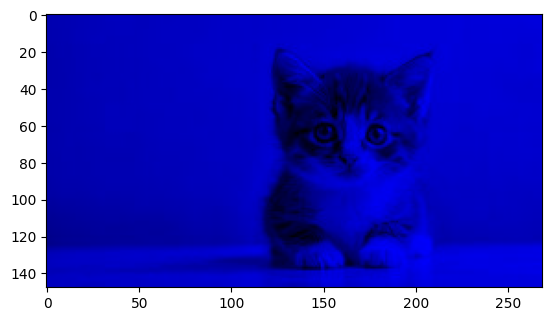

In [13]:
redd = img_array.copy()
redd[:, :, 0] = 0  # zero out red
redd[:, :, 1] = 0  # zero out green

plt.imshow(redd)
plt.show()


> rotate
Why (1,0,2)?
Because:
axis 1 becomes first
axis 0 becomes second
RGB stays same
So:
(H, W, 3) -> (W, H, 3)

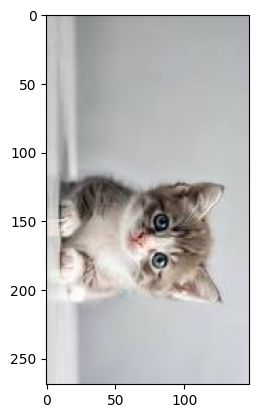

In [10]:
transpose=img_array.transpose(1,0,2)

rotate=transpose[:,::-1]
plt.imshow(rotate)
plt.show()

>blur
replace each pixel
with average of nearby pixels

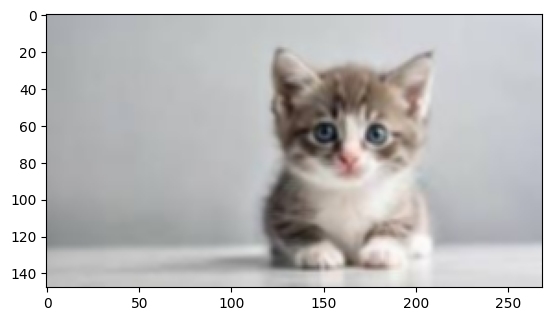

In [14]:
blurred = img_array.copy()

for i in range(1, img_array.shape[0]-1):
    for j in range(1, img_array.shape[1]-1):

        blurred[i, j] = np.mean(
            img_array[i-1:i+2, j-1:j+2],
            axis=(0,1)
        )


plt.imshow(blurred.astype(np.uint8))
plt.show()

To be frank, I had heard from various sources that “images are just arrays,” and I used to nod along until I actually got into working with NumPy. And guess what? I had no clue whatsoever.When I looked at an image, I saw a picture. My brain processed it as a whole thing — a cat, a face, a sunset. But NumPy doesn't see any of that. NumPy sees a table of numbers. And the moment I truly accepted that, everything clicked.

Grayscale (2D Array):Shape: \((Height, Width)\)Data: A single matrix where each pixel value represents intensity (typically 0 for black to 255 for white).RGB (3D Array):Shape: \((Height, Width, 3)\)Data: Three stacked 2D matrices representing the Red, Green, and Blue color channels.RGBA (3D Array):Shape: \((Height, Width, 4)\)Data: Includes the three RGB channels plus a 4th Alpha channel for transparency (0 is fully transparent, 255 is fully opaque).